Enter the following paths (absolute/relative supported):
1. Path to latitude/longitude Excel file: C:\Users\cugli\Desktop\冀东数据处理后结果\JD_DATA_ID.xlsx
2. Output folder (leave empty for current directory): 

Reading column names...
✅ All columns in file:
  1. Sampel ID
  2. Reference No.
  3. Sample No.
  4. Rock name
  5. Rock Type
  6. Geological unit
  7. Geographic location
  8. latitude
  9. longitude
  10. Drilling depth

Select column number for [Rock Type] (1-10): 5
✅ Selected: [Rock Type] as rock type classification


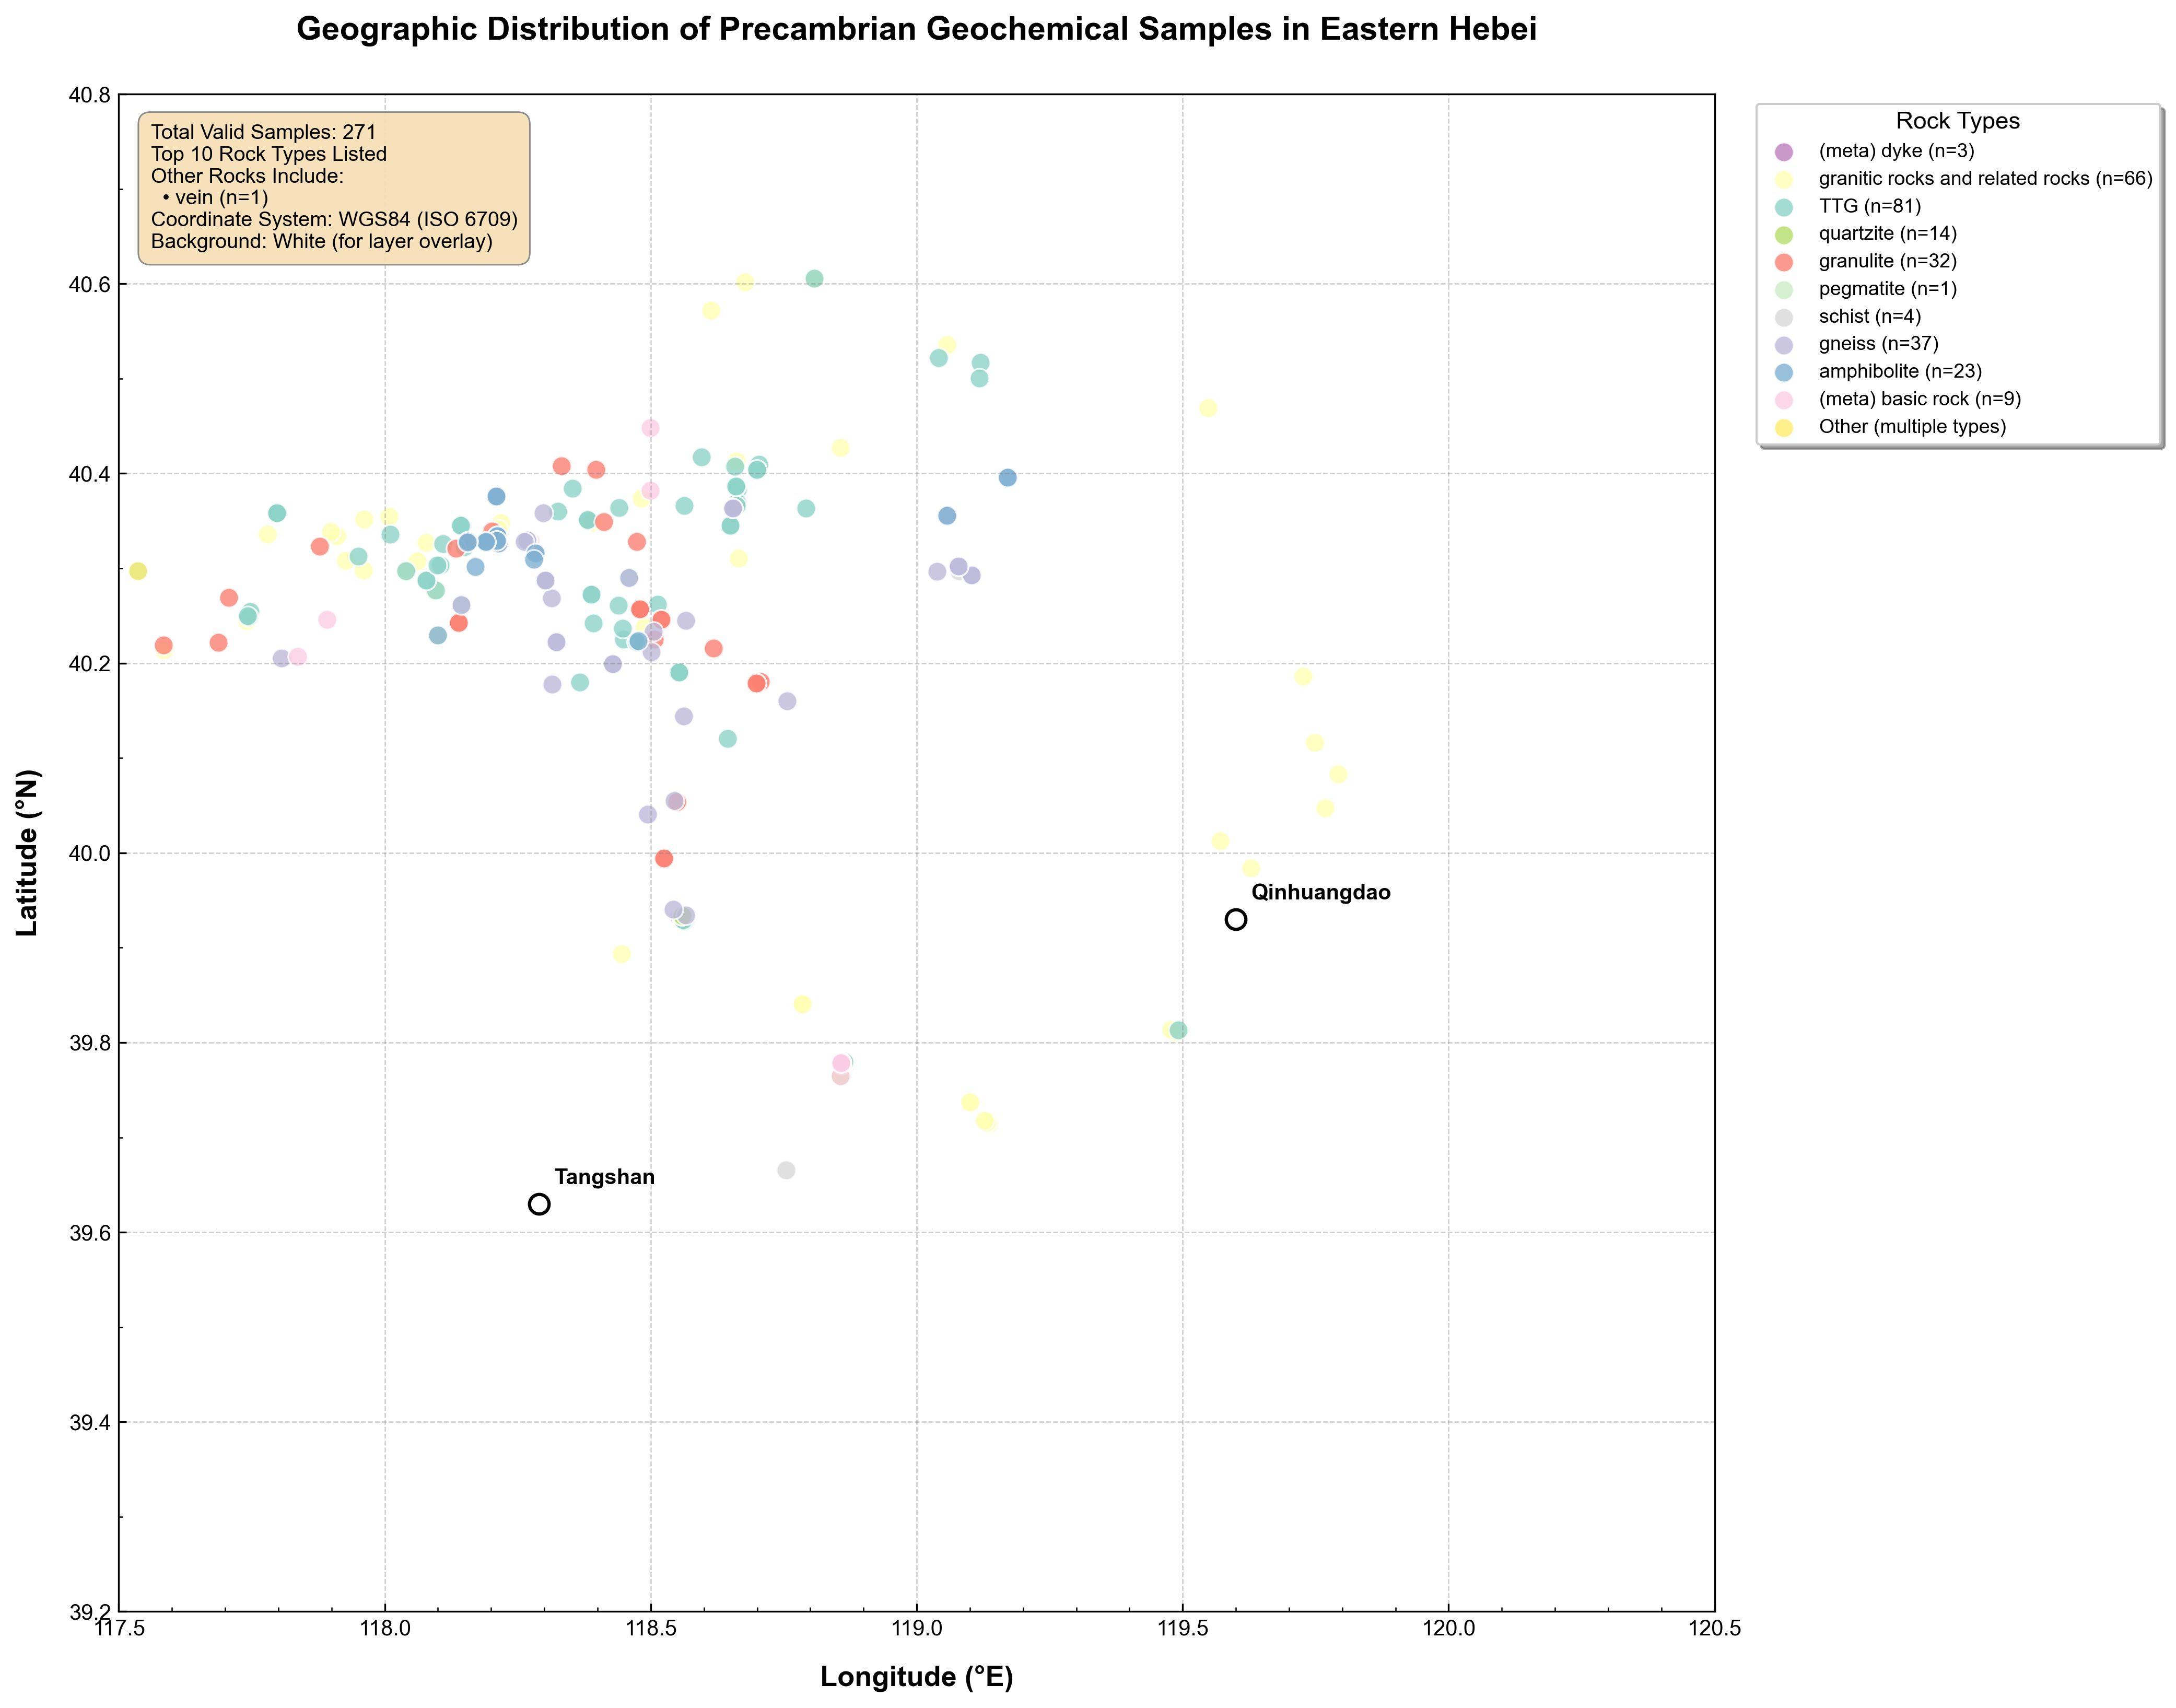


=== Rock Type Statistics ===
 1. vein: 1 samples

Other type total: 1 rock types, 1 samples

✅ Plot completed! SVG saved to: C:\Users\cugli\Desktop\冀东数据处理后结果\jupyter\final_sample_distribution_map.svg


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
import os

# ========== Suppress all warnings ==========
warnings.filterwarnings('ignore')

# ===================== Interactive file input =====================
print("Enter the following paths (absolute/relative supported):")
while True:
    excel_path = input("1. Path to latitude/longitude Excel file: ").strip()
    if os.path.exists(excel_path):
        break
    print(f"Error: File {excel_path} not found, please re-enter!")

output_dir = input("2. Output folder (leave empty for current directory): ").strip()
if not output_dir:
    output_dir = os.getcwd()
elif not os.path.exists(output_dir):
    os.makedirs(output_dir)

# SVG output path
svg_filename = "final_sample_distribution_map.svg"
svg_path = os.path.join(output_dir, svg_filename)

# ===================== Select rock type column =====================
print("\nReading column names...")
df_sample = pd.read_excel(excel_path, nrows=1)
all_columns = df_sample.columns.tolist()
print("✅ All columns in file:")
for idx, col in enumerate(all_columns, 1):
    print(f"  {idx}. {col}")

while True:
    try:
        choice = int(input(f"\nSelect column number for [Rock Type] (1-{len(all_columns)}): "))
        if 1 <= choice <= len(all_columns):
            ROCK_COLUMN = all_columns[choice - 1]
            break
        else:
            print(f"Enter a number between 1 and {len(all_columns)}!")
    except ValueError:
        print("Invalid input, enter a number!")

print(f"✅ Selected: [{ROCK_COLUMN}] as rock type classification")

# ===================== Plot style settings =====================
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# ===================== Data loading & filtering =====================
sample_df = pd.read_excel(excel_path)
lat_col = 'latitude'
lon_col = 'longitude'
rock_col = ROCK_COLUMN

valid_data = sample_df.dropna(subset=[lat_col, lon_col, rock_col])
valid_data = valid_data[(valid_data[lat_col] >= 39) & (valid_data[lat_col] <= 41) &
                        (valid_data[lon_col] >= 117.5) & (valid_data[lon_col] <= 121)]

rock_counts = valid_data[rock_col].value_counts()
top_10_rocks = rock_counts.head(10).index.tolist()
other_rocks = rock_counts.tail(-10).index.tolist() if len(rock_counts) > 10 else []

valid_data['rock_label'] = valid_data[rock_col].apply(
    lambda x: f"{x} (n={rock_counts[x]})" if x in top_10_rocks
    else f"Other (n={rock_counts[x]})"
)

# ===================== Plotting =====================
fig, ax = plt.subplots(1, 1, figsize=(14, 11))
ax.set_xlim(117.5, 120.5)
ax.set_ylim(39.2, 40.8)
ax.grid(True, alpha=0.4, linestyle='--', color='gray', linewidth=0.6)

# 0.1° minor ticks
ax.set_xticks(np.arange(117.5, 120.6, 0.5))
ax.set_xticks(np.arange(117.5, 120.6, 0.1), minor=True)
ax.set_yticks(np.arange(39.2, 40.9, 0.2))
ax.set_yticks(np.arange(39.2, 40.9, 0.1), minor=True)
ax.tick_params(which='minor', length=2, color='black', width=0.6)

# Color mapping
n_colors = len(top_10_rocks) + 1
colors = plt.cm.Set3(np.linspace(0, 1, n_colors))
color_map = {f"{rock} (n={rock_counts[rock]})": colors[i] for i, rock in enumerate(top_10_rocks)}
color_map["Other (multiple types)"] = colors[-1]

valid_data['final_rock_label'] = valid_data['rock_label'].apply(
    lambda x: x if x.split(" (n=")[0] in top_10_rocks
    else "Other (multiple types)"
)

# Plot sample points
for label in valid_data['final_rock_label'].unique():
    subset = valid_data[valid_data['final_rock_label'] == label]
    ax.scatter(subset[lon_col], subset[lat_col],
               color=color_map[label], label=label,
               s=80, alpha=0.8, edgecolors='white', linewidth=0.8, marker='o')

# City markers
geo_markers = {
    'Tangshan': (118.29, 39.63),
    'Qinhuangdao': (119.60, 39.93),
    'Chengde': (117.93, 40.97),
    'Beijing': (116.40, 39.90)
}
for city, (lon, lat) in geo_markers.items():
    ax.plot(lon, lat, 'ko', markersize=9, markerfacecolor='white', markeredgewidth=1.5, markeredgecolor='black')
    ax.annotate(city, (lon, lat), xytext=(7, 7), textcoords='offset points',
                fontsize=10, fontweight='bold', ha='left', va='bottom', color='black')

# Axis labels
ax.set_xlabel('Longitude (°E)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Latitude (°N)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_title('Geographic Distribution of Precambrian Geochemical Samples in Eastern Hebei',
             fontsize=15, fontweight='bold', pad=25)

# Legend
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9,
          title='Rock Types', title_fontsize=11, frameon=True,
          fancybox=True, shadow=True, ncol=1, columnspacing=0.8)

# Statistics text box
other_text = ""
if other_rocks:
    other_text = '\n'.join([f"  • {rock} (n={rock_counts[rock]})" for rock in other_rocks[:8]]) + \
                 (f"\n  • ... and {len(other_rocks)-8} more types" if len(other_rocks) > 8 else "")
else:
    other_text = "  • No other rock types"

stats_text = f'Total Valid Samples: {len(valid_data):,}\nTop 10 Rock Types Listed\nOther Rocks Include:\n' + \
             other_text + \
             f"\nCoordinate System: WGS84 (ISO 6709)\nBackground: White (for layer overlay)"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6',
                                          facecolor='wheat', alpha=0.9,
                                          edgecolor='gray', linewidth=0.7))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(svg_path, format='svg', bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()
plt.close()

# ===================== Output statistics =====================
print("\n=== Rock Type Statistics ===")
if other_rocks:
    for i, rock in enumerate(other_rocks, 1):
        print(f"{i:2d}. {rock}: {rock_counts[rock]} samples")
    other_total = rock_counts.tail(-10).sum() if len(rock_counts) > 10 else 0
    print(f"\nOther type total: {len(other_rocks)} rock types, {other_total} samples")
else:
    print("No other rock types")

print(f"\n✅ Plot completed! SVG saved to: {svg_path}")